# Goal of this notebook:

I want to recreate Table 1 from https://arxiv.org/pdf/2112.05176 where the times for mGST are shown.
The idea would be to show that our algorithm is faster already for 2Q and 3Q.
This means our algorithm not only allows to perform 4Q GST but also makes smaller GST's significantly cheaper.

We need to use the same parameters as the authors did for 2Q and 3Q GST to make it fair:

* Single qubit: length 7, 1000 shots per sequence, 92 sequence
* Two qubits: length 7, 1000 shots, 900-something sequences
* Three qubits: length 7, 1000 shots, 1974 sequences

In [78]:
%load_ext autoreload
%autoreload 2
from iqm.benchmarks.compressive_gst.compressive_gst import CompressiveGST
from mGST.qiskit_interface import qiskit_gate_to_operator
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, get_compressed_perturbed_kraus_from_superop, kraus_tensor_to_mgst
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

import jax.numpy as jnp

backend = "iqmfakeapollo"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup (parameters, configuration and initial tensors)

In [65]:
depth = 7
num_shots = 1000
num_seq_1q = 92
num_seq_2q = 900
num_se_3q = 1974
kraus_rank_1 = 1
kraus_rank_2 = 2
kraus_rank_4 = 4
kraus_rank_16 = 16

num_qubits_2 = 2
dim_2q = 2 ** num_qubits_2
state_rank_2q = dim_2q
povm_rank_2q = dim_2q

num_qubits_3 = 3
dim_3q = 2 ** num_qubits_3
state_rank_3q = dim_3q
povm_rank_3q = dim_3q

# Running experiment

In [ ]:
# This will be reused for all rank's in 2Q system. Since the rank passsed here is just symbolic.
# This rank is only accesed later from the data set to factorize into kraus psd (we do this manually outside)
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_seq_2q,
    shots=num_shots,
    rank=1,
)

kraus_tensor_mgst_2q_rank_1, kraus_mgst_2q_rank_1, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-02-24 22:04:34,455 - iqm.benchmarks.logging_config - INFO - Generating 900 random GST circuits
2026-02-24 22:04:34,973 - iqm.benchmarks.logging_config - INFO - Will transpile all 900 circuits according to fixed physical layout
2026-02-24 22:04:35,312 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-02-24 22:04:37,908 - iqm.benchmarks.logging_config - INFO - Submitting batch with 900 circuits corresponding to qubits [0, 1]
2026-02-24 22:04:37,922 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-02-24 22:04:37,981 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-02-24 22:04:38,041 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-02-24 22:04:39,219 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-02-24 22:04:41,196 - iqm.benchmarks.logging_config - INFO - Run complet

In [12]:
povm_psd_init_2q, state_psd_init_2q = get_compressed_perturbed_rep_from_mgst(povm_mgst_2q, state_mgst_2q)
cost_fn_kwargs_2q = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q,
    "jit": True,
}

In [11]:
# Kraus is already perturbed
kraus_tensor_init_2q_rank_1 = jnp.array(kraus_tensor_mgst_2q_rank_1)

In [79]:
# Obtain unperturbed Kraus
benchmark = CompressiveGST(backend, Q2_GST)
gate_set = benchmark.gate_set
kraus_tensor_target = qiskit_gate_to_operator(gate_set)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_target.shape

(6, 16, 16)

In [80]:
# Just checking that our compressed perturbed function actually works.
kraus_rank_1_test_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=1, seed=42)
jnp.allclose(kraus_rank_1_test_dict["kraus_tensor"], kraus_tensor_init_2q_rank_1)

Array(True, dtype=bool)

In [82]:
# Now let's get the higher rank ones
kraus_tensor_init_2q_rank_2 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=2, seed=42)["kraus_tensor"]
kraus_tensor_init_2q_rank_4 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=4, seed=42)["kraus_tensor"]
kraus_tensor_init_2q_rank_16 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=16, seed=42)["kraus_tensor"]

# Gathering initial operators

In [13]:
init_operators_jax_2q_rank_1 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_1,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_2q_rank_1, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value:", initial_cost_value)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/low_level_jit.py:640: UserWarning: Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.
  warnings.warn("Kraus rank = 1 detected. Using the coherent version of the cost function for better performance.")


at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value: 0.005212969035191423


In [83]:
init_operators_jax_2q_rank_2 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_2,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_2 = cost_function_jax_mps(kraus_tensor_init_2q_rank_2, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 2):", initial_cost_value_rank_2)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value (rank 2): 0.004871851761458866


In [84]:
init_operators_jax_2q_rank_4 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_4,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_4 = cost_function_jax_mps(kraus_tensor_init_2q_rank_4, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 4):", initial_cost_value_rank_4)

at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 7 the new count changed to: 18
at iteration 43 the new count changed to: 19
at iteration 110 the new count changed to: 20
at iteration 178 the new count changed to: 21
at iteration 246 the new count changed to: 22
at iteration 314 the new count changed to: 23
at iteration 382 the new count changed to: 24
at iteration 450 the new count changed to: 25
at iteration 525 the new count changed to: 26
at iteration 600 the new count changed to: 27
at iteration 675 the new count changed to: 28
at iteration 750 the new count changed to: 29
at iteration 825 the new count changed to: 30
Initial cost value (rank 4): 0.002007014388562367


In [85]:
init_operators_jax_2q_rank_16 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_16,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_16 = cost_function_jax_mps(kraus_tensor_init_2q_rank_16, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 16):", initial_cost_value_rank_16)

at iteration 0 the new count changed to: 31
at iteration 1 the new count changed to: 32
at iteration 7 the new count changed to: 33
at iteration 43 the new count changed to: 34
at iteration 110 the new count changed to: 35
at iteration 178 the new count changed to: 36
at iteration 246 the new count changed to: 37
at iteration 314 the new count changed to: 38
at iteration 382 the new count changed to: 39
at iteration 450 the new count changed to: 40
at iteration 525 the new count changed to: 41
at iteration 600 the new count changed to: 42
at iteration 675 the new count changed to: 43
at iteration 750 the new count changed to: 44
at iteration 825 the new count changed to: 45
Initial cost value (rank 16): 0.001585834105323851


# Optimization

## Setup

In [38]:
num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-6
kappa = 1/10
theta = 1 # should have been 1!

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [89]:
noise_threshold = estimate_noise_floor_threshold(prob_matrix_2q, num_shots, multiplier=3.0)
noise_threshold

Array(0.00045373, dtype=float64)

In [92]:
len(indices_list_2q) == num_seq_2q

True

In [93]:
num_povm_test = prob_matrix_2q.shape[0]
3*(1-prob_matrix_2q.reshape(-1))@prob_matrix_2q.reshape(-1)/num_seq_2q/num_povm_test/num_shots

0.0004537305783333328

## 2Q

## Rank 1

In [ ]:
# This was run using theta = 0.5 and without a noise threshold stopping criteria. Which meant all the optimization were performed.
optimized_operators_2q_rank_1_threshold, cost_fn_history_2q_rank_1_threshold = run_riemannian_optimization(
    **init_operators_jax_2q_rank_1,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True, # to be able to plot cost function history for each operator optimization step
    noise_threshold=noise_threshold,
    verbose=True,
) # 3mins 51.9s

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.212969e-03. |r∇f(x)|: 6.809384e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 4.712858e-03. |r∇f(x)|: 3.354995e-03. Radius: 2.00e-01
TCG finished after: 6/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 4.519373e-03. |r∇f(x)|: 2.217323e-04. Radius: 4.00e-01
TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 3. f(x): 4.518544e-03. |r∇f(x)|: 1.086850e-05. Radius: 8.00e-01
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
-----------------------------

In [128]:
# have the unmodified noise threshold together with convergence based on relative precision
relative_precision = 1e-5
og_noise_threshold = estimate_noise_floor_threshold(prob_matrix_2q, num_shots, multiplier=1.0)
og_noise_threshold

Array(0.00015124, dtype=float64)

In [ ]:
optimized_operators_2q_rank_1_rel_precision, cost_fn_history_2q_rank_1_rel_precision= run_riemannian_optimization(
    **init_operators_jax_2q_rank_1,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True, # to be able to plot cost function history for each operator optimization step
    noise_threshold=og_noise_threshold,
    relative_precision=relative_precision,
    verbose=True, # 18 mins 22.3s
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Noise Threshold 📶 1.51e-04 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.212969e-03. |r∇f(x)|: 6.809384e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 4.712858e-03. |r∇f(x)|: 3.354995e-03. Radius: 2.00e-01
TCG finished after: 6/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 4.519373e-03. |r∇f(x)|: 2.217323e-04. Radius: 4.00e-01
TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 3. f(x): 4.518544e-03. |r∇f(x)|: 1.086850e-05. Radius: 8.00

In [108]:
len(cost_fn_history_2q_rank_1_rel_precision)

141

In [127]:
print(f"{jnp.abs(5.212969e-03 - 1.763443e-03)/(5.212969e-03 + 1):.2e}")

3.43e-03


In [126]:
print(f"{jnp.abs(1.763443e-03 - 2.076366e-04)/(1.763443e-03 + 1):.2e}")

1.55e-03


In [125]:
print(f"{jnp.abs(2.076366e-04 - 1.847270e-04)/(2.076366e-04 + 1):.2e}")

2.29e-05


In [123]:
print(f"{jnp.abs(1.847270e-04 - 1.828069e-04)/(1.847270e-04 + 1):.2e}")

1.92e-06


In [124]:
print(f"{jnp.abs(1.828069e-04 - 1.825330e-04)/(1.828069e-04 + 1):.2e}")

2.74e-07


## Rank 2

In [90]:
optimized_operators_2q_rank_2, cost_fn_history_2q_rank_2 = run_riemannian_optimization(
    **init_operators_jax_2q_rank_2,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=noise_threshold,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
and convergence criteria: Noise Threshold 📶 4.54e-04
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 4.871852e-03. |r∇f(x)|: 1.119956e-02. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 3.981650e-03. |r∇f(x)|: 6.618694e-03. Radius: 2.00e-01
TCG finished after: 3/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 3.86e-05
---------------------------------------
TR Iteration: 2. f(x): 3.500338e-03. |r∇f(x)|: 1.137361e-04. Radius: 2.00e-01
TCG finished after: 7/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 3. f(x): 3.500147e-03. |r∇f(x)|: 1.347190e-07. Radius: 4.00e-01
TCG finished after: 2/10 iters. 
 Rea

In [95]:
cost_fn_history_2q_rank_1_threshold[-1], noise_threshold

(Array(0.00025197, dtype=float64), Array(0.00045373, dtype=float64))

## No threshold (old run)

In [ ]:
# This was run using theta = 0.5 and without a noise threshold stopping criteria. Which meant all the optimization were performed.
optimized_operators_2q_rank_1, cost_fn_history_2q_rank_1 = run_riemannian_optimization(
    **init_operators_jax_2q_rank_1,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True, # to be able to plot cost function history for each operator optimization step
    verbose=True,
) # 17mins 45.8s

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.212969e-03. |r∇f(x)|: 6.809384e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 4.712858e-03. |r∇f(x)|: 3.354995e-03. Radius: 2.00e-01
TCG finished after: 3/10 iters. 
 Reason: Stopping criteria met 🛑. |r_k| = 4.90e-05
---------------------------------------
TR Iteration: 2. f(x): 4.518629e-03. |r∇f(x)|: 7.116171e-05. Radius: 2.00e-01
TCG finished after: 4/10 iters. 
 Reason: Stopping criteria met 🛑. |r_k| = 1.40e-07
---------------------------------------
TR Iteration: 3. f(x): 4.518547e-03. |r∇f(x)|: 1.407654e-07. Radius: 2.00e-01
TCG finished after: 2/10 iters. 
 Reason: Negative curvature encountered 📉.
-------------

# Plotting

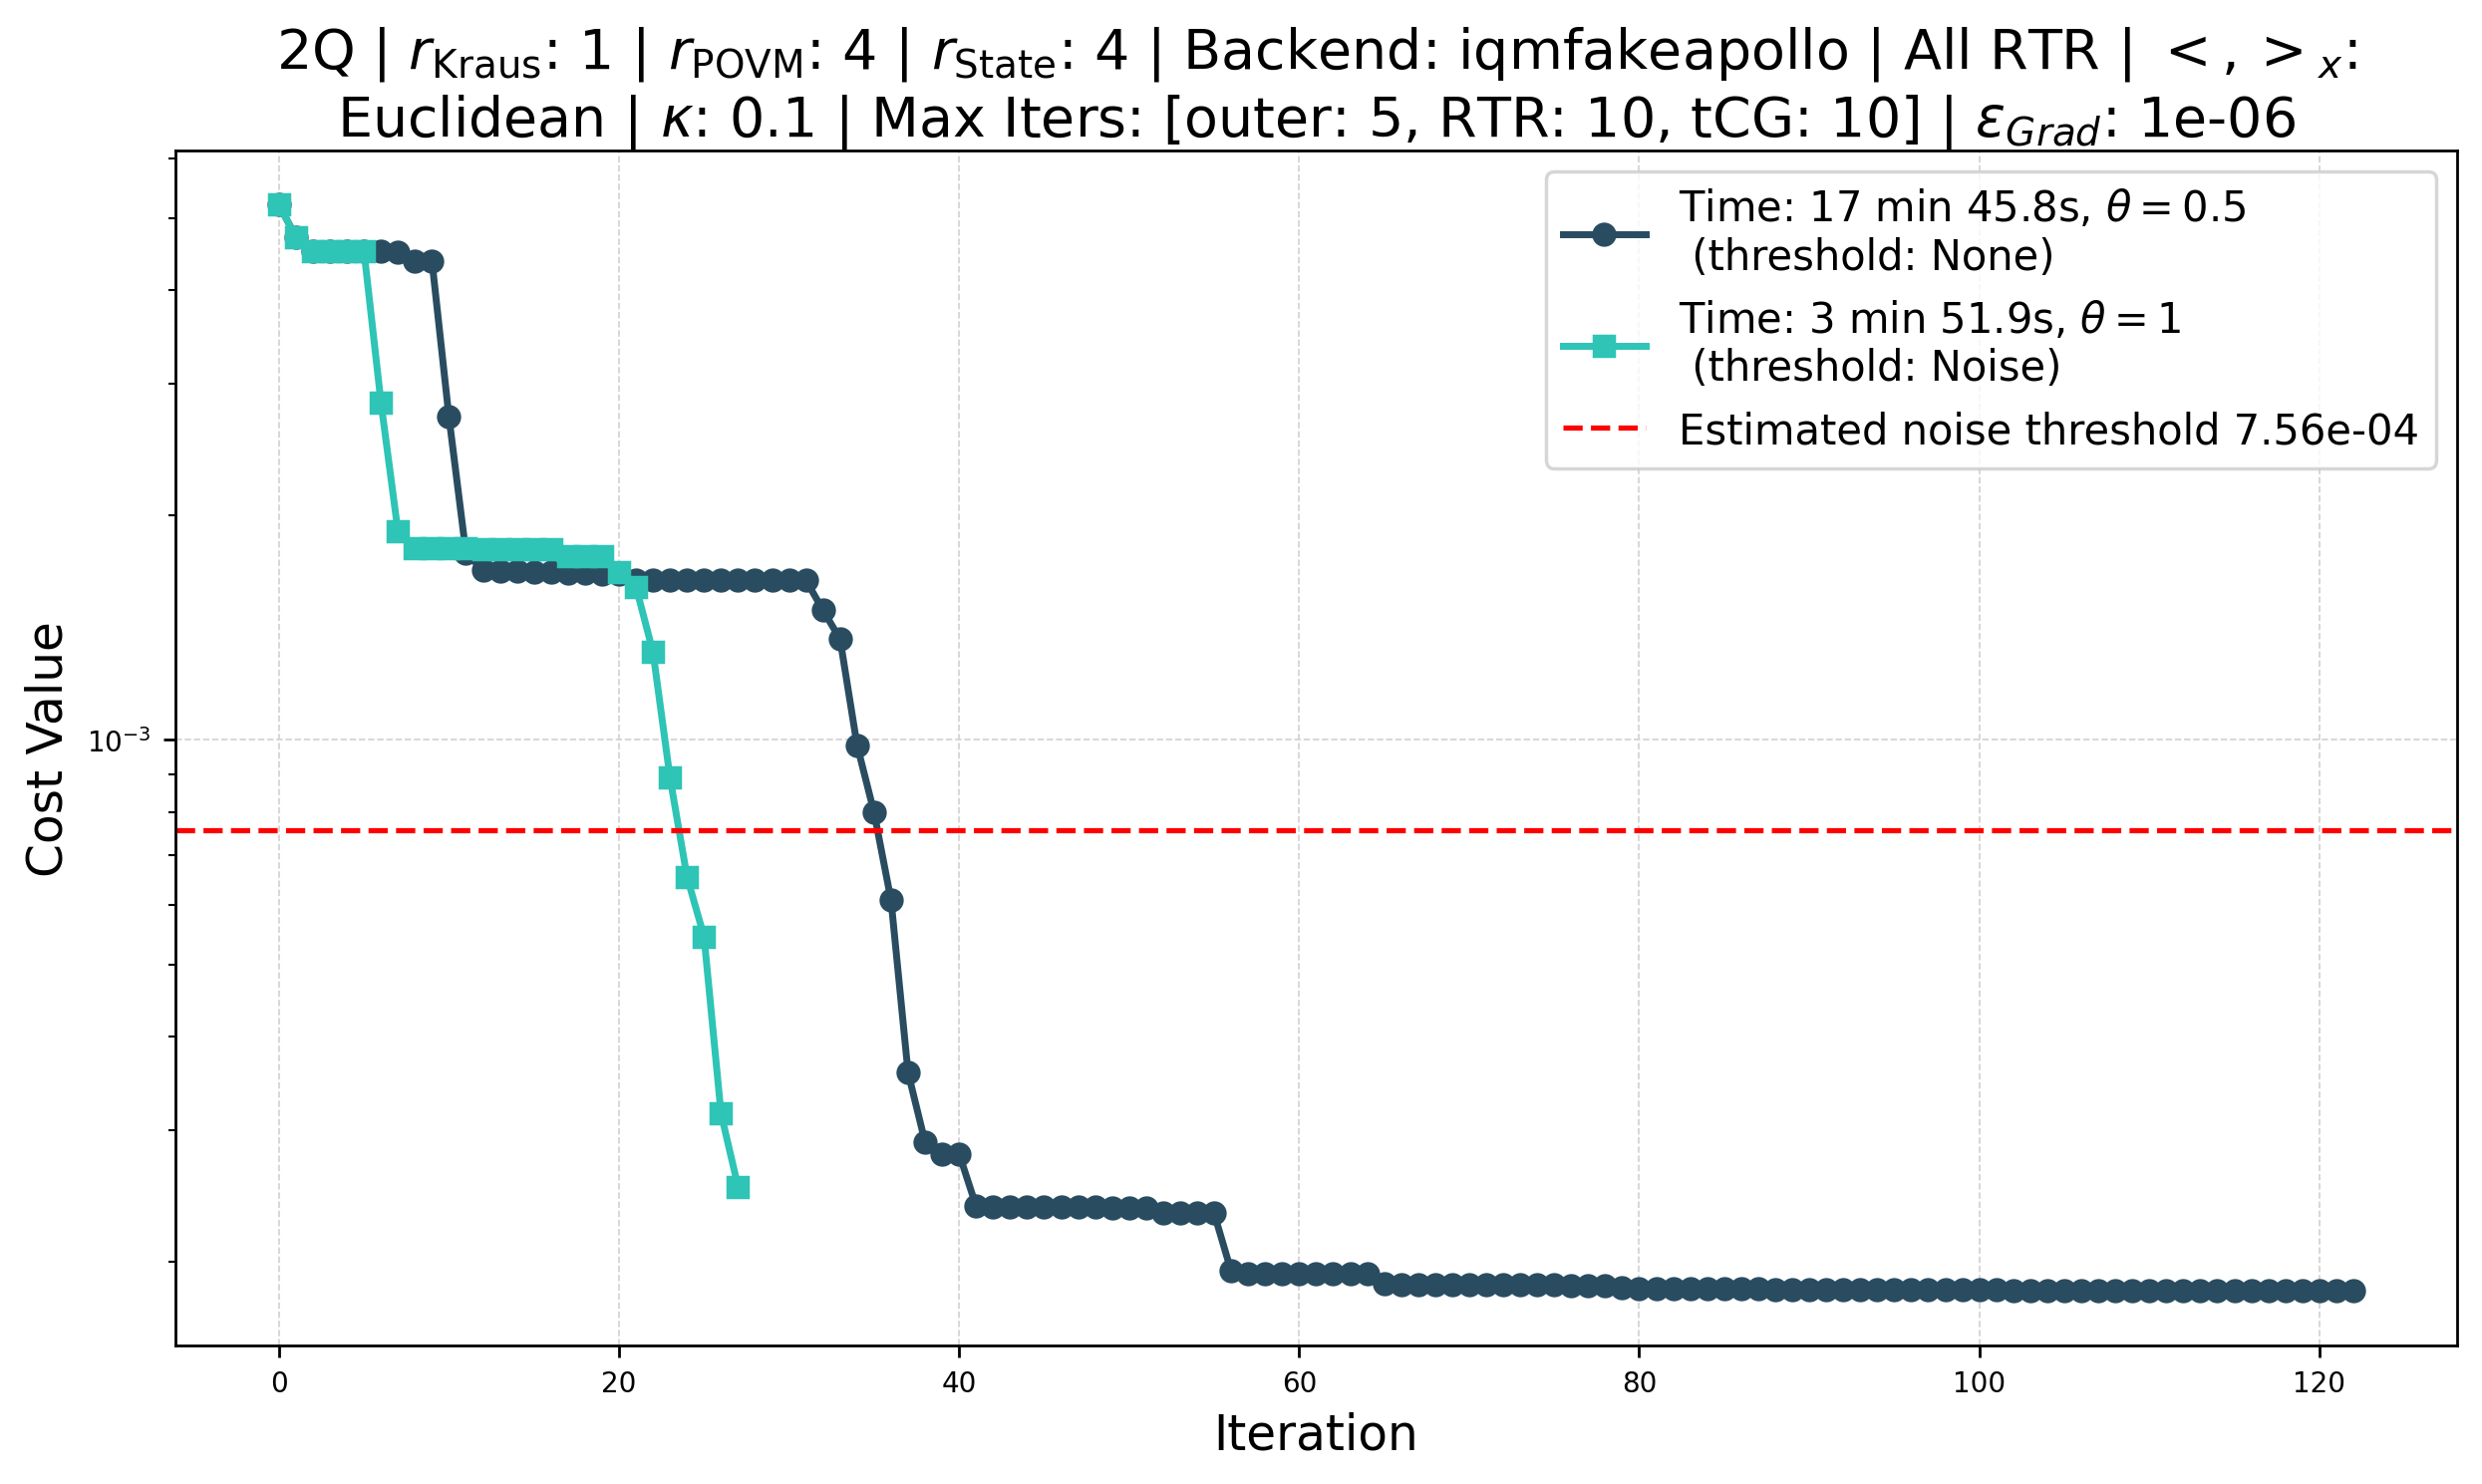

In [62]:
cost_fn_lists = [
    cost_fn_history_2q_rank_1,
    cost_fn_history_2q_rank_1_threshold
]

labels = [
    rf"Time: 17 min 45.8s, $\theta=${0.5}" + "\n (threshold: None)",
    rf"Time: 3 min 51.9s, $\theta=${theta}" + "\n (threshold: Noise)",
]

title = rf"{num_qubits_2}Q | $r_\mathrm{{Kraus}}$: {kraus_rank_1} | $r_\mathrm{{POVM}}$: {povm_rank_2q} | $r_\mathrm{{State}}$: {state_rank_2q} | Backend: {backend} | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad}"

plot_cost_function(cost_fn_lists, title=title, labels=labels, comparison_yline=noise_threshold, comparison_label=f"Estimated noise threshold {noise_threshold:.2e}")

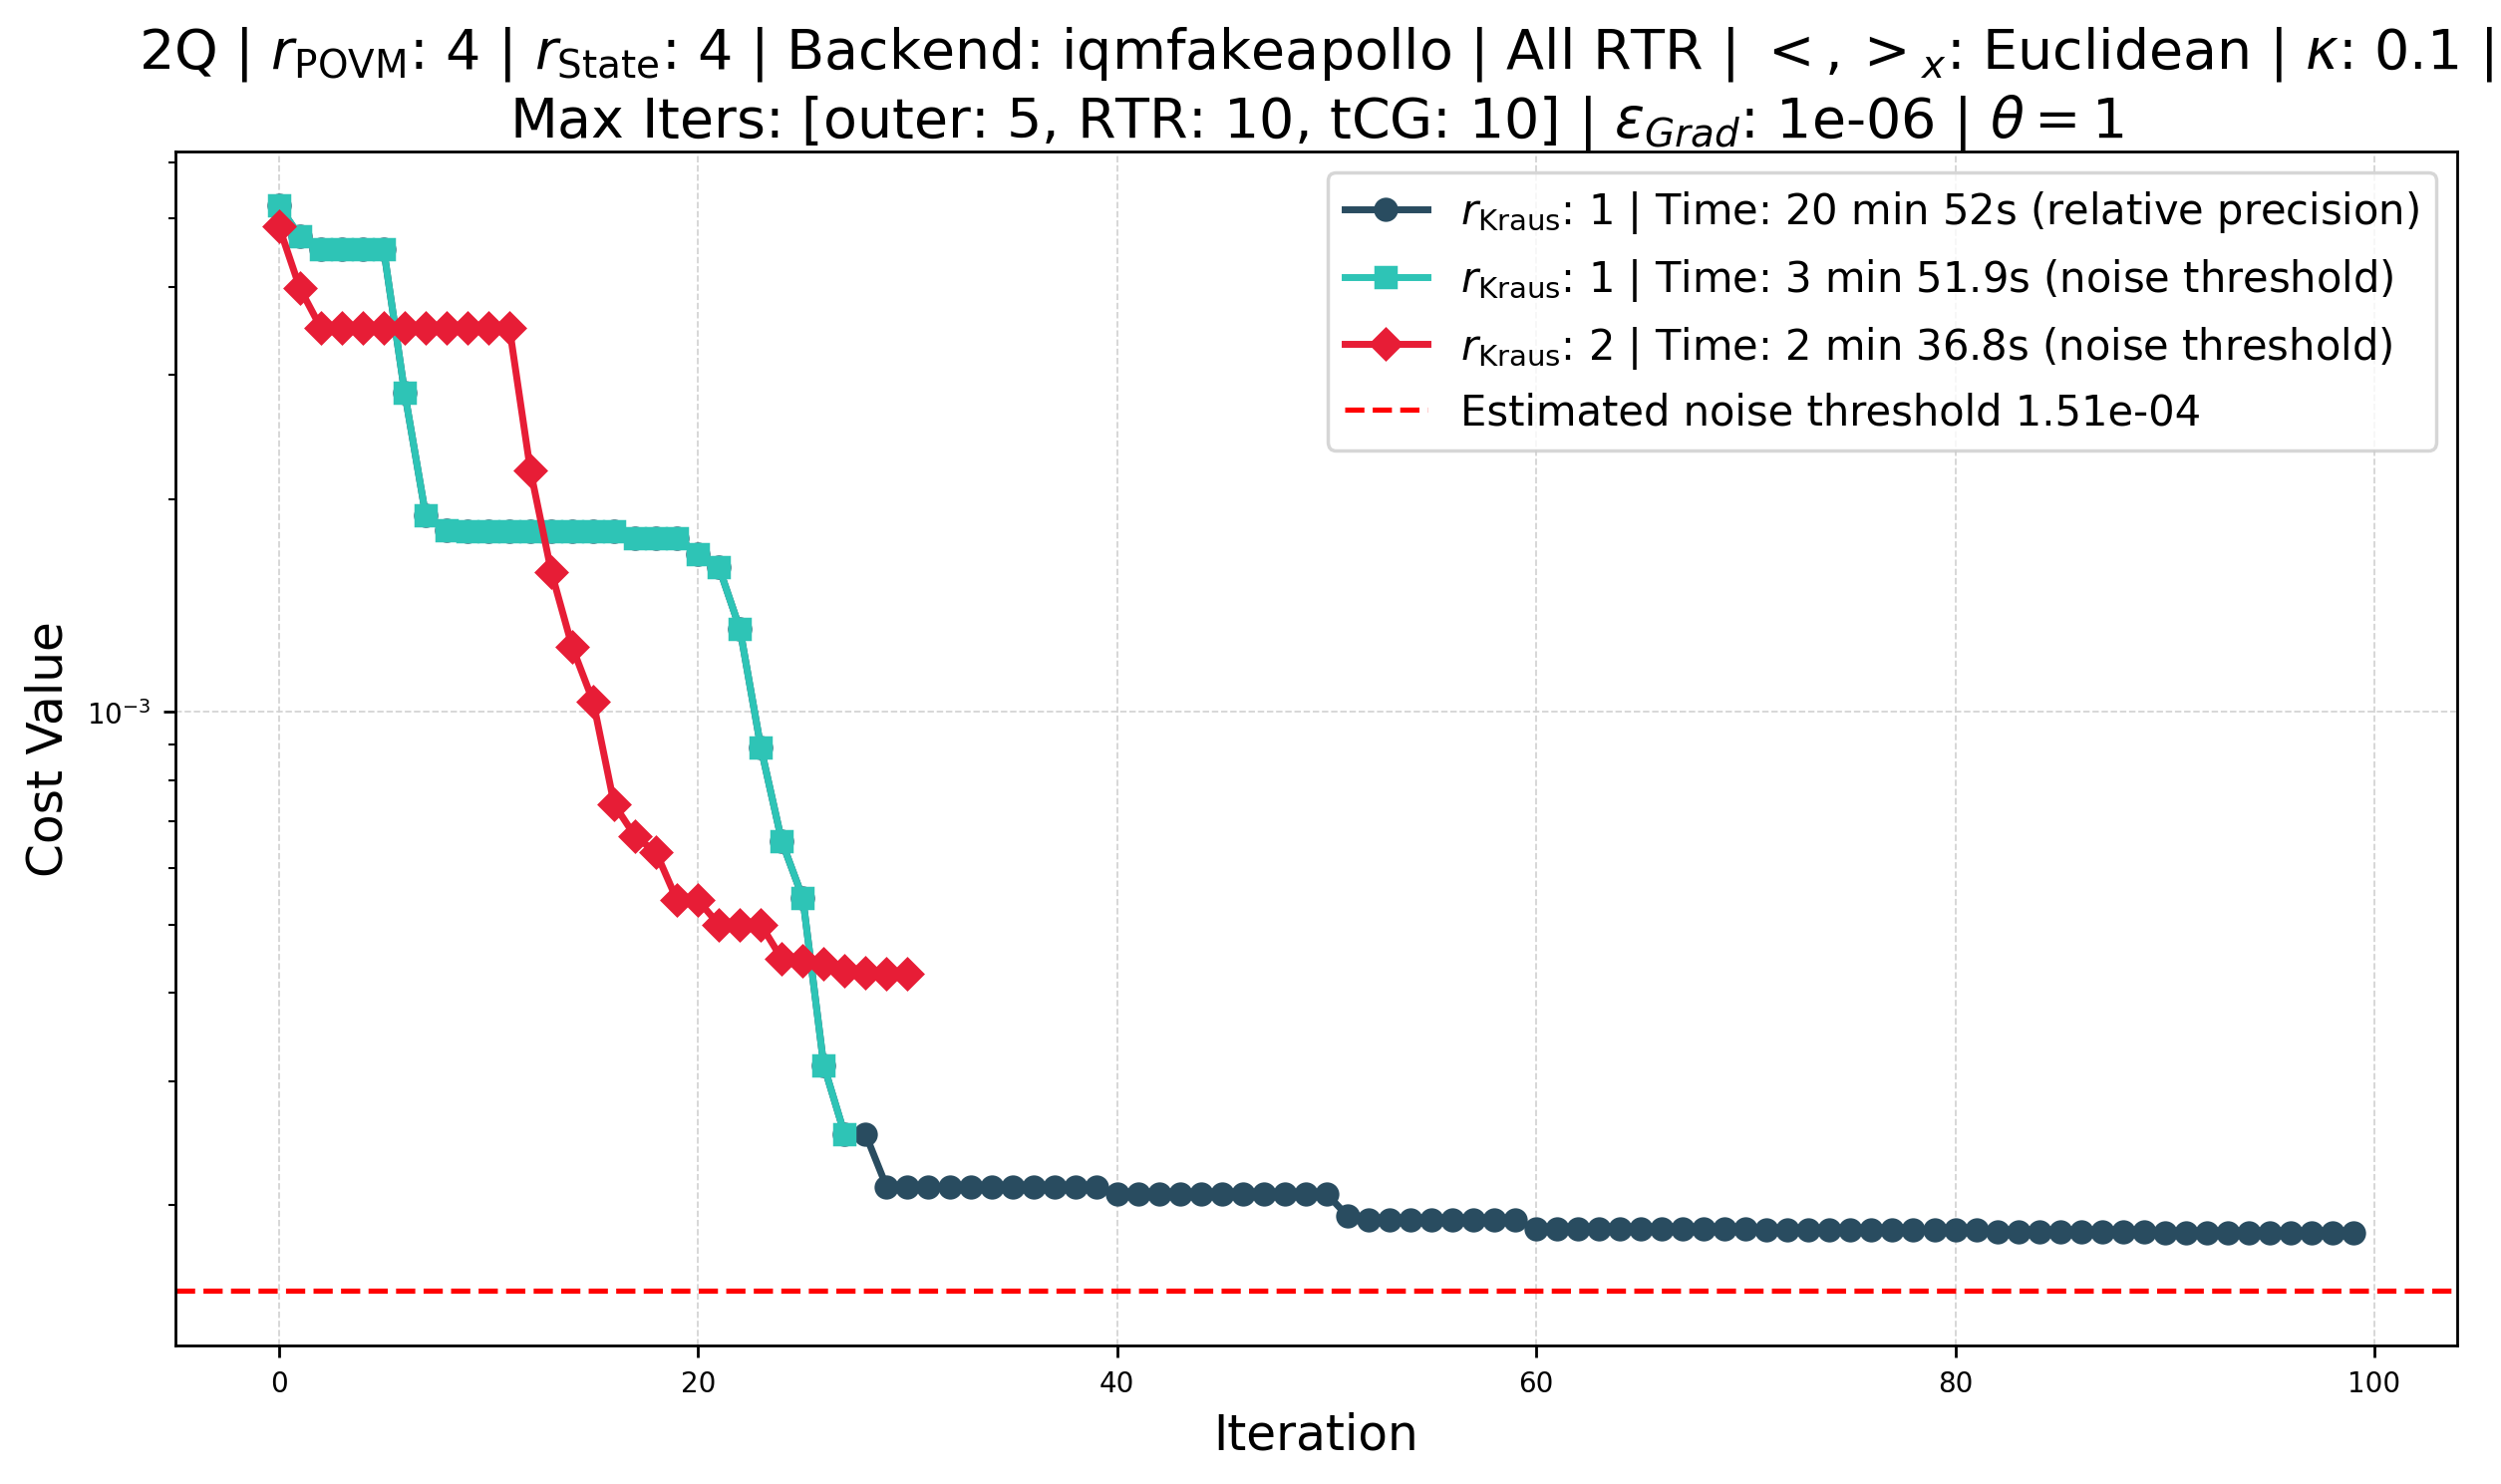

In [131]:
cost_fn_lists_ranks = [
    cost_fn_history_2q_rank_1_rel_precision,
    cost_fn_history_2q_rank_1_threshold,
    cost_fn_history_2q_rank_2,
]

labels_ranks = [
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank_1} | Time: 20 min 52s (relative precision)",
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank_1} | Time: 3 min 51.9s (noise threshold)",
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank_2} | Time: 2 min 36.8s (noise threshold)",
]

title_ranks = rf"{num_qubits_2}Q | $r_\mathrm{{POVM}}$: {povm_rank_2q} | $r_\mathrm{{State}}$: {state_rank_2q} | Backend: {backend} | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta}"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=og_noise_threshold, comparison_label=f"Estimated noise threshold {og_noise_threshold:.2e}")

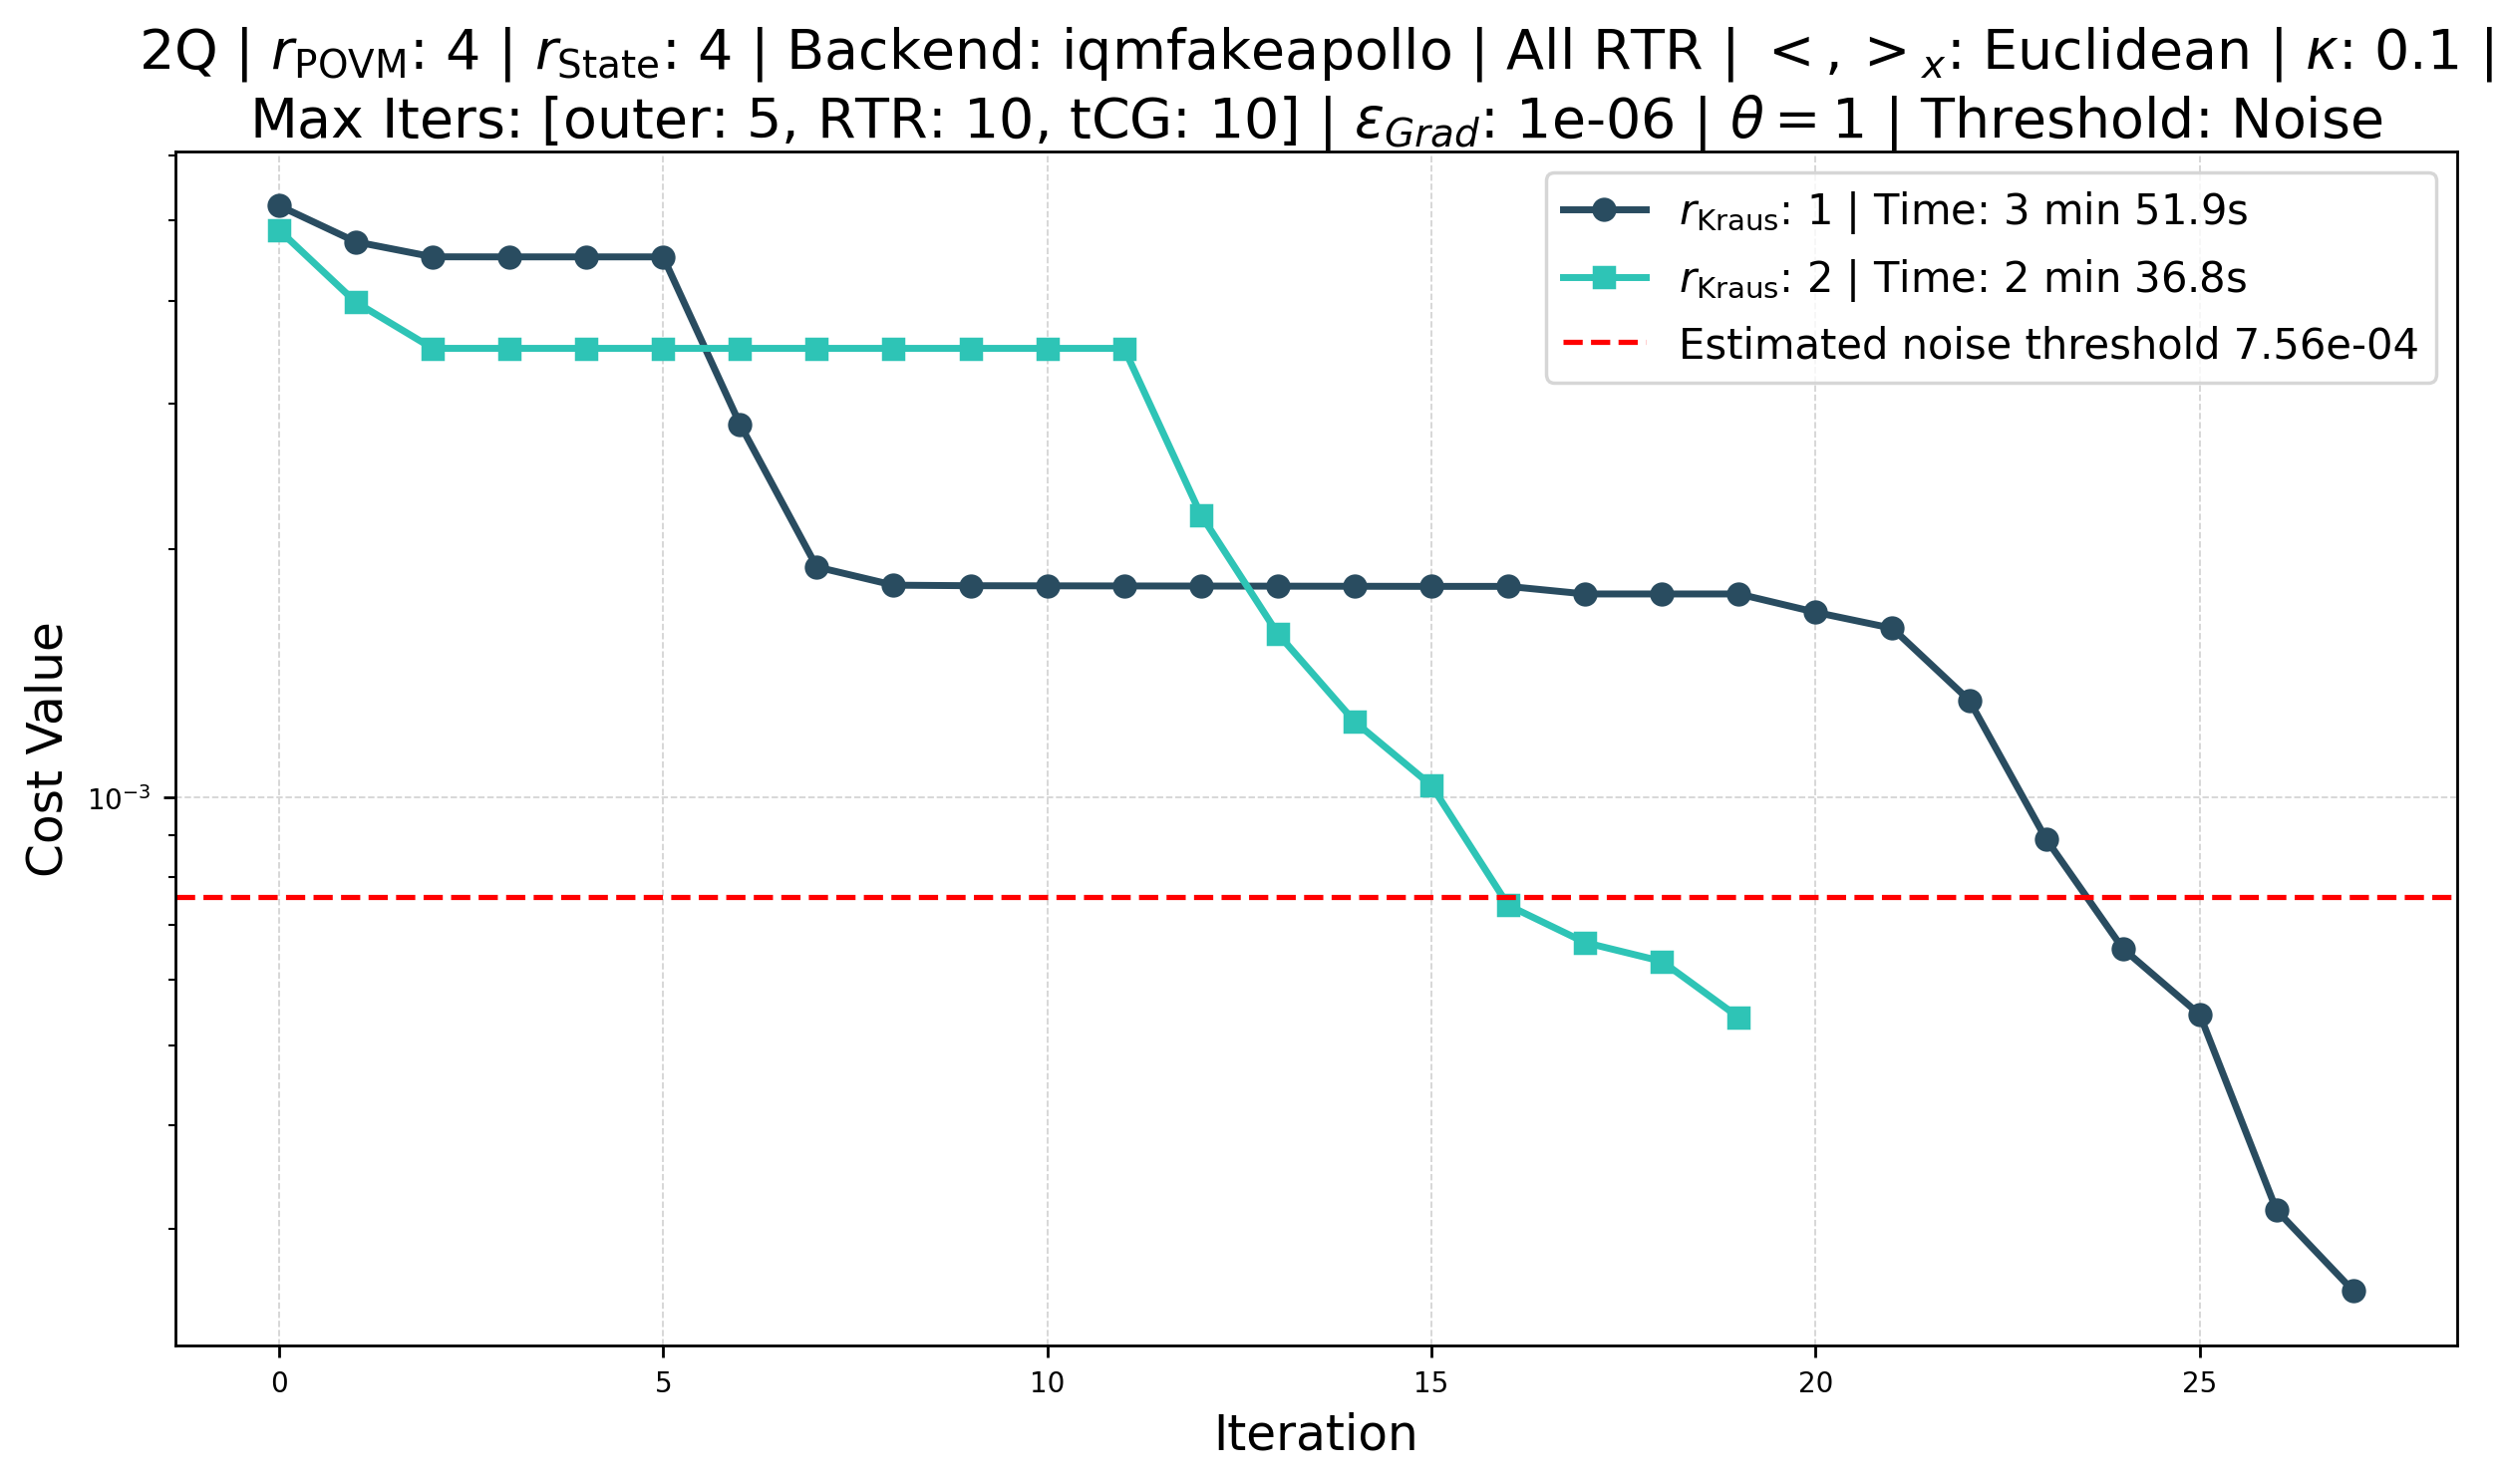

In [87]:
cost_fn_lists_ranks = [
    cost_fn_history_2q_rank_1_threshold,
    cost_fn_history_2q_rank_2
]

labels_ranks = [
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank_1} | Time: 3 min 51.9s",
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank_2} | Time: 2 min 36.8s "
]

title_ranks = rf"{num_qubits_2}Q | $r_\mathrm{{POVM}}$: {povm_rank_2q} | $r_\mathrm{{State}}$: {state_rank_2q} | Backend: {backend} | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta} | Threshold: Noise"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=noise_threshold, comparison_label=f"Estimated noise threshold {noise_threshold:.2e}")

# Save data

In [63]:
# save the cost function trajectories with and without threshold
jnp.savez("cost_fn_sets_2q_rank_1.npz",
          no_threshold_theta_05 = cost_fn_history_2q_rank_1,
          noise_threshold_theta_1 = cost_fn_history_2q_rank_1_threshold,)

# Learnings:
* Based on the cost function trajectory for the latest run, it seems like having a stopping criteria based on the cost function decrease from povm to next povm is a good candidate to stop the optimization. Similar to what raphael does. Right now the current criteria (stopping when all 3 RTR have stopped due to gradient norm) is not working. 
    * TODO: Add this in outer loop.

# Ideas:

* for 4Q: re-use the value of the riemannian hessian-vector product so it's not needed again in the quality quotient
(decrease prefactor by half)
* Add a dictionary to keep track of the length of each RTR optimization for the operators. This can be returned to be used in the plotting of cost fn colour coded based on the operators.